In [4]:
import pandas as pd

import pandas as pd
def line2latex(line, skip_cols=[12, 13], std_prefix='\\tiny'):
    latex_str = ''
    last_idx = len(line) - 1
    means = []
    stds = []
    for idx, cell in enumerate(line):
        # print(cell)
        if idx in skip_cols:
            continue
        if '±' in cell:
            # print(cell)
            mean, std = cell.split('±')
            # print(mean, std)
            std_str = f'±{std}'
            latex_str += f'{mean}{std_prefix}{{{std_str}}}'
            means.append(mean)
            stds.append(std)
        elif cell == '':
            latex_str += '-'
            means.append(None)
            stds.append(None)
        else:
            latex_str += cell
        if idx != last_idx:
            latex_str += ' & '
        else:
            latex_str += '\\\\'
    print(latex_str)
        # break
    return pd.DataFrame({'means': means, 'stds': stds})

def _print_imb_line_stats(line):
    df_line = line2latex(line.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
    df_line.means = df_line.means.astype(float)
    df_line.stds = df_line.stds.astype(float)
    print('Overall mean and std:', df_line.means.mean(), df_line.stds.mean())
    print('Even pos mean and std:', df_line.means[0::2].mean(), df_line.stds[0::2].mean())
    print('Odd pos mean and std:', df_line.means[1::2].mean(), df_line.stds[1::2].mean())
    return df_line

In [8]:
s = """fullysupervised	5.69±0.15	5.72±0.13	5.78±0.07	5.73±0.11	36.4±0.05	36.4±0.05	24.87±0.04	24.84±0.04	32.04±0.03	32.04±0.03	20.951				
supervised	20.31±2.79	14.02±1.22	15.06±1.08	14.25±0.97	52.31±1.28	47.53±0.69	37.43±0.29	33.26±0.1	51.22±0.98	46.71±0.37	33.21				"""

In [10]:
lines = s.split('\n')

In [13]:
lines[0].split('\t')

['fullysupervised',
 '5.69±0.15',
 '5.72±0.13',
 '5.78±0.07',
 '5.73±0.11',
 '36.4±0.05',
 '36.4±0.05',
 '24.87±0.04',
 '24.84±0.04',
 '32.04±0.03',
 '32.04±0.03',
 '20.951',
 '',
 '',
 '',
 '']

In [77]:
line2latex(lines[0].split('\t'))

fullysupervised & 5.69\tiny{±0.15} & 5.72\tiny{±0.13} & 5.78\tiny{±0.07} & 5.73\tiny{±0.11} & 36.4\tiny{±0.05} & 36.4\tiny{±0.05} & 24.87\tiny{±0.04} & 24.84\tiny{±0.04} & 32.04\tiny{±0.03} & 32.04\tiny{±0.03} & 20.951 & - & -\\


In [79]:
line2latex(lines[0].split('\t'), std_prefix='\scalebox{.5}')

fullysupervised & 5.69\scalebox{.5}{±0.15} & 5.72\scalebox{.5}{±0.13} & 5.78\scalebox{.5}{±0.07} & 5.73\scalebox{.5}{±0.11} & 36.4\scalebox{.5}{±0.05} & 36.4\scalebox{.5}{±0.05} & 24.87\scalebox{.5}{±0.04} & 24.84\scalebox{.5}{±0.04} & 32.04\scalebox{.5}{±0.03} & 32.04\scalebox{.5}{±0.03} & 20.951 & - & -\\


In [65]:
for line in lines:
    line2latex(line.split('\t'))

fullysupervised & 5.69\tiny{±0.15} & 5.72\tiny{±0.13} & 5.78\tiny{±0.07} & 5.73\tiny{±0.11} & 36.4\tiny{±0.05} & 36.4\tiny{±0.05} & 24.87\tiny{±0.04} & 24.84\tiny{±0.04} & 32.04\tiny{±0.03} & 32.04\tiny{±0.03} & 20.951 & - & -\\
supervised & 20.31\tiny{±2.79} & 14.02\tiny{±1.22} & 15.06\tiny{±1.08} & 14.25\tiny{±0.97} & 52.31\tiny{±1.28} & 47.53\tiny{±0.69} & 37.43\tiny{±0.29} & 33.26\tiny{±0.1} & 51.22\tiny{±0.98} & 46.71\tiny{±0.37} & 33.21 & - & -\\


In [70]:
imb_str = """17.67±1.22	49.60±0.62	49.99±0.01	13.84±2.44	26.46±0.99	33.85±2.93	46.37±0.64	64.74±0.39	66.45±0.81	31.75±0.52	50.59±0.86	53.96±0.81	42.66±0.15	63.33±0.58	63.70±2.41
	49.17±0.88	26.05±6.28		21.11±0.49	25.36±2.60		61.03±1.64	59.66±2.58		41.01±0.79	41.46±4.34			56.71±1.87"""

In [71]:
for line in imb_str.split('\n'):
    line2latex(line.split('\t'), skip_cols=[0, 3, 6, 9, 12])

49.60\tiny{±0.62} & 49.99\tiny{±0.01} & 26.46\tiny{±0.99} & 33.85\tiny{±2.93} & 64.74\tiny{±0.39} & 66.45\tiny{±0.81} & 50.59\tiny{±0.86} & 53.96\tiny{±0.81} & 63.33\tiny{±0.58} & 63.70\tiny{±2.41}\\
49.17\tiny{±0.88} & 26.05\tiny{±6.28} & 21.11\tiny{±0.49} & 25.36\tiny{±2.60} & 61.03\tiny{±1.64} & 59.66\tiny{±2.58} & 41.01\tiny{±0.79} & 41.46\tiny{±4.34} & - & 56.71\tiny{±1.87}\\


In [5]:
results_table_str="""fullysupervised	5.69±0.15	5.72±0.13	5.78±0.07	5.73±0.11	36.4±0.05	36.4±0.05	24.87±0.04	24.84±0.04	32.04±0.03	32.04±0.03	20.95				
supervised	20.31±2.79	14.02±1.22	15.06±1.08	14.25±0.97	52.31±1.28	47.53±0.69	37.43±0.29	33.26±0.1	51.22±0.98	46.71±0.37	33.21				
pseudolabel	45.45±4.43	19.67±1.01	19.49±3.07	14.69±1.88	53.45±1.9	47.0±0.79	37.7±0.65	32.72±0.31	54.51±0.82	47.33±0.2	37.20	19	18.3	15.30	16
meanteacher	20.06±2.51	13.97±1.49	15.17±1.21	13.93±0.65	52.14±0.52	47.66±0.84	37.09±0.18	33.43±0.28	50.6±0.62	47.21±0.31	33.13	16	17.1	14.10	14
pimodel	49.99±0.01	44.75±3.99	60.7±19.09	12.58±0.57	77.22±1.5	53.17±2.56	44.91±1.32	32.45±0.45	75.73±4.01	59.82±0.61	51.13	21	19.6	16.60	17
vat	25.93±2.58	11.61±1.79	14.7±1.19	11.71±0.84	49.83±0.46	46.54±0.31	34.87±0.41	31.5±0.35	52.97±1.41	45.3±0.32	32.50	17	14.6	11.90	13
mixmatch	26.12±6.13	15.47±0.65	13.5±1.51	11.75±0.6	59.54±0.67	61.69±3.32	35.75±0.71	33.62±0.14	53.98±0.59	51.7±0.68	36.31	18	16.9	14.30	15
remixmatch	50.0±0.0	50.0±0.0	75.0±0.0	75.0±0.0	80.0±0.0	80.0±0.0	90.0±0.0	90.0±0.0	80.0±0.0	80.0±0.0	75.00	22	21.9	18.90	19
adamatch	8.09±0.99	7.11±0.2	11.73±0.17	11.22±0.95	46.72±0.72	42.27±0.25	32.75±0.35	30.44±0.31	45.4±0.96	40.16±0.49	27.59	11	7.2	5.70	3
uda	49.97±0.04	50.0±0.0	41.0±24.96	53.68±30.15	60.76±13.61	68.38±16.44	71.3±26.45	70.5±27.58	69.33±15.08	66.95±18.46	60.19	20	20.6	17.60	18
fixmatch	7.72±0.33	7.33±0.13	30.17±1.87	11.71±1.95	47.61±0.83	43.05±0.54	33.03±0.49	30.51±0.53	46.52±0.94	40.65±0.46	29.83	7	11.3	8.70	10
flexmatch	7.82±0.77	7.41±0.38	16.38±3.94	12.08±0.73	45.73±1.6	42.25±0.33	35.61±1.08	31.13±0.18	43.35±0.69	40.51±0.34	28.23	9	10.6	8.10	8
dash	8.34±0.86	7.55±0.35	31.67±13.19	13.76±1.67	47.1±0.74	43.09±0.6	35.26±0.33	31.19±0.29	45.24±2.02	40.14±0.79	30.33	12	13	10.30	11
crmatch	8.96±0.88	7.16±0.09	12.28±1.43	11.08±1.24	45.49±0.98	43.07±0.5	32.51±0.4	29.98±0.07	45.71±0.63	40.62±0.28	27.69	15	8.3	6.40	5
comatch	7.44±0.3	7.72±1.14	11.95±0.76	10.75±0.35	48.76±0.9	43.36±0.21	33.48±0.51	30.25±0.35	45.4±1.12	40.27±0.51	27.94	5	9.1	7.10	7
simmatch	7.93±0.55	7.08±0.33	14.26±1.51	12.45±1.37	45.91±0.95	42.21±0.3	33.06±0.2	30.16±0.21	46.12±0.48	40.26±0.62	27.94	10	8.7	6.60	6
freematch	8.94±0.21	7.95±0.45	12.98±0.58	11.73±0.63	46.41±0.6	42.64±0.06	32.77±0.26	30.32±0.18	47.95±1.45	40.37±1.0	28.21	14	10.6	8.40	9
softmatch	7.76±0.58	7.97±0.72	11.9±0.27	11.72±1.58	45.29±0.95	42.21±0.2	33.07±0.31	30.44±0.62	44.09±0.5	39.76±0.13	27.42	8	7.5	5.70	3
multihead_cotraining	8.70±0.88	7.46±0.68	22.72±6.09	13.48±1.51	46.22±0.70	43.07±0.79	35.17±1.58	30.81±0.28	46.46±1.28	40.79±0.49	29.49			10.50	12
marginmatch	7.19±0.39	6.99±0.19	10.65±0.19	11.03±0.99	44.81±1.23	42.14±0.67	32.08±0.70	29.55±0.15	42.93±1.48	39.13±0.34	26.65	3	2.1	1.70	2
multihead_apm4+FR_3x3	7.09±0.24	6.98±0.20	11.18±0.66	10.56±0.63	44.11±0.79	41.99±0.18	31.14±0.61	29.59±0.27	43.37±0.65	39.17±0.31	26.52			1.50	1"""

In [80]:
for line in results_table_str.split('\n'):
    line2latex(line.split('\t'), std_prefix='\scalebox{.6}')

fullysupervised & 5.69\scalebox{.6}{±0.15} & 5.72\scalebox{.6}{±0.13} & 5.78\scalebox{.6}{±0.07} & 5.73\scalebox{.6}{±0.11} & 36.4\scalebox{.6}{±0.05} & 36.4\scalebox{.6}{±0.05} & 24.87\scalebox{.6}{±0.04} & 24.84\scalebox{.6}{±0.04} & 32.04\scalebox{.6}{±0.03} & 32.04\scalebox{.6}{±0.03} & 20.95 & - & -\\
supervised & 20.31\scalebox{.6}{±2.79} & 14.02\scalebox{.6}{±1.22} & 15.06\scalebox{.6}{±1.08} & 14.25\scalebox{.6}{±0.97} & 52.31\scalebox{.6}{±1.28} & 47.53\scalebox{.6}{±0.69} & 37.43\scalebox{.6}{±0.29} & 33.26\scalebox{.6}{±0.1} & 51.22\scalebox{.6}{±0.98} & 46.71\scalebox{.6}{±0.37} & 33.21 & - & -\\
pseudolabel & 45.45\scalebox{.6}{±4.43} & 19.67\scalebox{.6}{±1.01} & 19.49\scalebox{.6}{±3.07} & 14.69\scalebox{.6}{±1.88} & 53.45\scalebox{.6}{±1.9} & 47.0\scalebox{.6}{±0.79} & 37.7\scalebox{.6}{±0.65} & 32.72\scalebox{.6}{±0.31} & 54.51\scalebox{.6}{±0.82} & 47.33\scalebox{.6}{±0.2} & 37.20 & 15.30 & 16\\
meanteacher & 20.06\scalebox{.6}{±2.51} & 13.97\scalebox{.6}{±1.49} & 15.

In [50]:
results_table_str = """Fully-Supervised	5.69±0.15	5.72±0.13	5.78±0.07	5.73±0.11	36.4±0.05	36.4±0.05	24.87±0.04	24.84±0.04	32.04±0.03	32.04±0.03	20.95				
Supervised	20.31±2.79	14.02±1.22	15.06±1.08	14.25±0.97	52.31±1.28	47.53±0.69	37.43±0.29	33.26±0.1	51.22±0.98	46.71±0.37	33.21				
Pseudo-Labeling	45.45±4.43	19.67±1.01	19.49±3.07	14.69±1.88	53.45±1.9	47.0±0.79	37.7±0.65	32.72±0.31	54.51±0.82	47.33±0.2	37.20	20	19.3	15.30	16
Mean Teacher 	20.06±2.51	13.97±1.49	15.17±1.21	13.93±0.65	52.14±0.52	47.66±0.84	37.09±0.18	33.43±0.28	50.6±0.62	47.21±0.31	33.13	17	18.1	14.10	14
$\Pi$-Model	49.99±0.01	44.75±3.99	60.7±19.09	12.58±0.57	77.22±1.5	53.17±2.56	44.91±1.32	32.45±0.45	75.73±4.01	59.82±0.61	51.13	22	20.6	16.60	17
VAT	25.93±2.58	11.61±1.79	14.7±1.19	11.71±0.84	49.83±0.46	46.54±0.31	34.87±0.41	31.5±0.35	52.97±1.41	45.3±0.32	32.50	18	15.6	11.90	13
MixMatch	26.12±6.13	15.47±0.65	13.5±1.51	11.75±0.6	59.54±0.67	61.69±3.32	35.75±0.71	33.62±0.14	53.98±0.59	51.7±0.68	36.31	19	17.9	14.30	15
ReMixMatch	50.0±0.0	50.0±0.0	75.0±0.0	75.0±0.0	80.0±0.0	80.0±0.0	90.0±0.0	90.0±0.0	80.0±0.0	80.0±0.0	75.00	23	22.9	18.90	19
AdaMatch	8.09±0.99	7.11±0.2	11.73±0.17	11.22±0.95	46.72±0.72	42.27±0.25	32.75±0.35	30.44±0.31	45.4±0.96	40.16±0.49	27.59	12	8.2	5.70	3
UDA	49.97±0.04	50.0±0.0	41.0±24.96	53.68±30.15	60.76±13.61	68.38±16.44	71.3±26.45	70.5±27.58	69.33±15.08	66.95±18.46	60.19	21	21.6	17.60	18
FixMatch	7.72±0.33	7.33±0.13	30.17±1.87	11.71±1.95	47.61±0.83	43.05±0.54	33.03±0.49	30.51±0.53	46.52±0.94	40.65±0.46	29.83	8	12.3	8.70	10
FlexMatch	7.82±0.77	7.41±0.38	16.38±3.94	12.08±0.73	45.73±1.6	42.25±0.33	35.61±1.08	31.13±0.18	43.35±0.69	40.51±0.34	28.23	10	11.6	8.20	8
Dash	8.34±0.86	7.55±0.35	31.67±13.19	13.76±1.67	47.1±0.74	43.09±0.6	35.26±0.33	31.19±0.29	45.24±2.02	40.14±0.79	30.33	13	14	10.30	11
CRMatch	8.96±0.88	7.16±0.09	12.28±1.43	11.08±1.24	45.49±0.98	43.07±0.5	32.51±0.4	29.98±0.07	45.71±0.63	40.62±0.28	27.69	16	9.3	6.40	5
CoMatch	7.44±0.3	7.72±1.14	11.95±0.76	10.75±0.35	48.76±0.9	43.36±0.21	33.48±0.51	30.25±0.35	45.4±1.12	40.27±0.51	27.94	6	10.1	7.10	7
SimMatch	7.93±0.55	7.08±0.33	14.26±1.51	12.45±1.37	45.91±0.95	42.21±0.3	33.06±0.2	30.16±0.21	46.12±0.48	40.26±0.62	27.94	11	9.7	6.60	6
FreeMatch	8.94±0.21	7.95±0.45	12.98±0.58	11.73±0.63	46.41±0.6	42.64±0.06	32.77±0.26	30.32±0.18	47.95±1.45	40.37±1.0	28.21	15	11.6	8.40	9
SoftMatch	7.76±0.58	7.97±0.72	11.9±0.27	11.72±1.58	45.29±0.95	42.21±0.2	33.07±0.31	30.44±0.62	44.09±0.5	39.76±0.13	27.42	9	8.5	5.70	3
Multihead Co-training	8.70±0.88	7.46±0.68	22.72±6.09	13.48±1.51	46.22±0.70	43.07±0.79	35.17±1.58	30.81±0.28	46.46±1.28	40.79±0.49	29.49			10.50	12
MarginMatch	7.19±0.39	6.99±0.19	10.65±0.19	11.03±0.99	44.81±1.23	42.14±0.67	32.08±0.70	29.55±0.15	42.93±1.48	39.13±0.34	26.65	4	3	2.00	2
MultiMatch	6.89±0.07	6.98±0.27	11.14±0.96	10.59±0.66	44.43±0.98	42.09±0.28	30.90±0.70	29.39±0.39	42.16±0.79	39.08±0.55	26.37			1.10	1"""

In [51]:
for line in results_table_str.split('\n'):
    line2latex(line.split('\t'), std_prefix='\scalebox{.6}')

Fully-Supervised & 5.69\scalebox{.6}{±0.15} & 5.72\scalebox{.6}{±0.13} & 5.78\scalebox{.6}{±0.07} & 5.73\scalebox{.6}{±0.11} & 36.4\scalebox{.6}{±0.05} & 36.4\scalebox{.6}{±0.05} & 24.87\scalebox{.6}{±0.04} & 24.84\scalebox{.6}{±0.04} & 32.04\scalebox{.6}{±0.03} & 32.04\scalebox{.6}{±0.03} & 20.95 & - & -\\
Supervised & 20.31\scalebox{.6}{±2.79} & 14.02\scalebox{.6}{±1.22} & 15.06\scalebox{.6}{±1.08} & 14.25\scalebox{.6}{±0.97} & 52.31\scalebox{.6}{±1.28} & 47.53\scalebox{.6}{±0.69} & 37.43\scalebox{.6}{±0.29} & 33.26\scalebox{.6}{±0.1} & 51.22\scalebox{.6}{±0.98} & 46.71\scalebox{.6}{±0.37} & 33.21 & - & -\\
Pseudo-Labeling & 45.45\scalebox{.6}{±4.43} & 19.67\scalebox{.6}{±1.01} & 19.49\scalebox{.6}{±3.07} & 14.69\scalebox{.6}{±1.88} & 53.45\scalebox{.6}{±1.9} & 47.0\scalebox{.6}{±0.79} & 37.7\scalebox{.6}{±0.65} & 32.72\scalebox{.6}{±0.31} & 54.51\scalebox{.6}{±0.82} & 47.33\scalebox{.6}{±0.2} & 37.20 & 15.30 & 16\\
Mean Teacher  & 20.06\scalebox{.6}{±2.51} & 13.97\scalebox{.6}{±1.49

In [81]:
ablation1 = "7.08±0.32	7.01±0.31	10.93±0.43	10.73±0.62	44.47±1.11	42.17±0.18	31.24±0.47	29.64±0.51	44.06±1.28	39.41±0.46	26.67"
line2latex(ablation1.split('\t'), std_prefix='\scalebox{.6}')

7.08\scalebox{.6}{±0.32} & 7.01\scalebox{.6}{±0.31} & 10.93\scalebox{.6}{±0.43} & 10.73\scalebox{.6}{±0.62} & 44.47\scalebox{.6}{±1.11} & 42.17\scalebox{.6}{±0.18} & 31.24\scalebox{.6}{±0.47} & 29.64\scalebox{.6}{±0.51} & 44.06\scalebox{.6}{±1.28} & 39.41\scalebox{.6}{±0.46} & 26.67\\


In [82]:
ablation2 = "7.23±0.18	7.02±0.24	18.41±5.86	11.28±0.86	44.58±0.96	42.08±0.29	36.15±1.36	30.35±0.70	43.94±1.68	39.16±0.36	28.02"
line2latex(ablation2.split('\t'), std_prefix='\scalebox{.6}')

7.23\scalebox{.6}{±0.18} & 7.02\scalebox{.6}{±0.24} & 18.41\scalebox{.6}{±5.86} & 11.28\scalebox{.6}{±0.86} & 44.58\scalebox{.6}{±0.96} & 42.08\scalebox{.6}{±0.29} & 36.15\scalebox{.6}{±1.36} & 30.35\scalebox{.6}{±0.70} & 43.94\scalebox{.6}{±1.68} & 39.16\scalebox{.6}{±0.36} & 28.02\\


In [45]:
ablation3="6.88±0.14	7.46±0.50	15.77±3.04	11.66±0.18	44.57±0.80	42.31±0.36	32.13±0.45	30.35±0.26	44.68±0.89	39.99±0.22	27.58"
line2latex(ablation3.split('\t'), std_prefix='\scalebox{.6}')

6.88\scalebox{.6}{±0.14} & 7.46\scalebox{.6}{±0.50} & 15.77\scalebox{.6}{±3.04} & 11.66\scalebox{.6}{±0.18} & 44.57\scalebox{.6}{±0.80} & 42.31\scalebox{.6}{±0.36} & 32.13\scalebox{.6}{±0.45} & 30.35\scalebox{.6}{±0.26} & 44.68\scalebox{.6}{±0.89} & 39.99\scalebox{.6}{±0.22} & 27.58\\


In [47]:
ablation4 = "6.89±0.07	6.98±0.27	11.14±0.96	10.59±0.66	44.43±0.98	42.09±0.28	30.90±0.70	29.39±0.39	42.16±0.79	39.08±0.55	26.37"
line2latex(ablation4.split('\t'), std_prefix='\scalebox{.6}')

6.89\scalebox{.6}{±0.07} & 6.98\scalebox{.6}{±0.27} & 11.14\scalebox{.6}{±0.96} & 10.59\scalebox{.6}{±0.66} & 44.43\scalebox{.6}{±0.98} & 42.09\scalebox{.6}{±0.28} & 30.90\scalebox{.6}{±0.70} & 29.39\scalebox{.6}{±0.39} & 42.16\scalebox{.6}{±0.79} & 39.08\scalebox{.6}{±0.55} & 26.37\\


In [34]:
ablation_w0 = "7.19±0.29	7.20±0.17	11.80±0.88	10.53±0.27	44.19±0.79	42.13±0.27	31.12±0.75	29.63±0.31	43.20±1.24	39.61±0.14"
line2latex(ablation_w0.split('\t'), std_prefix='\scalebox{.6}')

7.19\scalebox{.6}{±0.29} & 7.20\scalebox{.6}{±0.17} & 11.80\scalebox{.6}{±0.88} & 10.53\scalebox{.6}{±0.27} & 44.19\scalebox{.6}{±0.79} & 42.13\scalebox{.6}{±0.27} & 31.12\scalebox{.6}{±0.75} & 29.63\scalebox{.6}{±0.31} & 43.20\scalebox{.6}{±1.24} & 39.61\scalebox{.6}{±0.14}\\


,means,stds
0,7.19,0.29
1,7.20,0.17
2,11.80,0.88
3,10.53,0.27
4,44.19,0.79
5,42.13,0.27
6,31.12,0.75
7,29.63,0.31
8,43.20,1.24
9,39.61,0.14


In [77]:
imb_marginmatch = "17.67±1.22	49.60±0.62	49.99±0.01	13.84±2.44	26.46±0.99	33.85±2.93	46.37±0.64	64.74±0.39	66.45±0.81	31.75±0.52	50.59±0.86	53.96±0.81	42.66±0.15	63.33±0.58	63.70±2.41"
imb_marginmatch_df = line2latex(imb_marginmatch.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_marginmatch_df.means.astype(float).mean()

49.60\scalebox{.6}{±0.62} & 49.99\scalebox{.6}{±0.01} & 26.46\scalebox{.6}{±0.99} & 33.85\scalebox{.6}{±2.93} & 64.74\scalebox{.6}{±0.39} & 66.45\scalebox{.6}{±0.81} & 50.59\scalebox{.6}{±0.86} & 53.96\scalebox{.6}{±0.81} & 63.33\scalebox{.6}{±0.58} & 63.70\scalebox{.6}{±2.41}\\


52.266999999999996

In [76]:
imb_multimatch = "	49.17±0.88	26.05±6.28		21.11±0.49	25.36±2.60		61.03±1.64	59.66±2.58		41.01±0.79	41.46±4.34		60.14±3.41	56.71±1.87"
imb_multimatch_df = line2latex(imb_multimatch.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_multimatch_df.means.astype(float).mean()

49.17\scalebox{.6}{±0.88} & 26.05\scalebox{.6}{±6.28} & 21.11\scalebox{.6}{±0.49} & 25.36\scalebox{.6}{±2.60} & 61.03\scalebox{.6}{±1.64} & 59.66\scalebox{.6}{±2.58} & 41.01\scalebox{.6}{±0.79} & 41.46\scalebox{.6}{±4.34} & 60.14\scalebox{.6}{±3.41} & 56.71\scalebox{.6}{±1.87}\\


44.17

In [79]:
imb_cotr = "	49.91±0.12	50.00±0.00		30.88±2.81	34.43±4.51		62.90±2.24	58.05±4.53		52.05±1.28	51.39±1.51		64.32±3.06	58.62±3.34"
imb_cotr_df = line2latex(imb_cotr.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_cotr_df.means.astype(float).mean()

49.91\scalebox{.6}{±0.12} & 50.00\scalebox{.6}{±0.00} & 30.88\scalebox{.6}{±2.81} & 34.43\scalebox{.6}{±4.51} & 62.90\scalebox{.6}{±2.24} & 58.05\scalebox{.6}{±4.53} & 52.05\scalebox{.6}{±1.28} & 51.39\scalebox{.6}{±1.51} & 64.32\scalebox{.6}{±3.06} & 58.62\scalebox{.6}{±3.34}\\


51.254999999999995

In [78]:
imb_fixmatch = "	49.95±0.06	49.92±0.14		31.95±5.30	36.09±6.50		64.69±0.92	61.93±4.41		51.64±0.75	52.78±1.45		65.57±3.19	57.43±6.22"
imb_fixmatch_df = line2latex(imb_fixmatch.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_fixmatch_df.means.astype(float).mean()

49.95\scalebox{.6}{±0.06} & 49.92\scalebox{.6}{±0.14} & 31.95\scalebox{.6}{±5.30} & 36.09\scalebox{.6}{±6.50} & 64.69\scalebox{.6}{±0.92} & 61.93\scalebox{.6}{±4.41} & 51.64\scalebox{.6}{±0.75} & 52.78\scalebox{.6}{±1.45} & 65.57\scalebox{.6}{±3.19} & 57.43\scalebox{.6}{±6.22}\\


52.19500000000001

In [80]:
imb_marginmatch_abc = "	45.04±4.14	42.55±12.85		23.74±2.77	17.88±0.75		59.98±1.45	55.71±3.13		48.48±9.07	52.75±2.71		61.43±3.15	55.42±0.33"
imb_marginmatch_abc_df = line2latex(imb_marginmatch_abc.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_marginmatch_abc_df.means.astype(float).mean()

45.04\scalebox{.6}{±4.14} & 42.55\scalebox{.6}{±12.85} & 23.74\scalebox{.6}{±2.77} & 17.88\scalebox{.6}{±0.75} & 59.98\scalebox{.6}{±1.45} & 55.71\scalebox{.6}{±3.13} & 48.48\scalebox{.6}{±9.07} & 52.75\scalebox{.6}{±2.71} & 61.43\scalebox{.6}{±3.15} & 55.42\scalebox{.6}{±0.33}\\


46.298

In [5]:
imb_multimatch_abc = "	48.81±1.98	17.21±3.78		29.36±11.90	19.65±4.39		62.13±1.46	57.12±0.88		41.05±1.34	42.72±2.57		60.71±2.68	53.87±3.03"
imb_multimatch_abc_df = line2latex(imb_multimatch_abc.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_multimatch_abc_df.means.astype(float).mean()


48.81\scalebox{.6}{±1.98} & 17.21\scalebox{.6}{±3.78} & 29.36\scalebox{.6}{±11.90} & 19.65\scalebox{.6}{±4.39} & 62.13\scalebox{.6}{±1.46} & 57.12\scalebox{.6}{±0.88} & 41.05\scalebox{.6}{±1.34} & 42.72\scalebox{.6}{±2.57} & 60.71\scalebox{.6}{±2.68} & 53.87\scalebox{.6}{±3.03}\\


43.26299999999999

In [6]:
imb_freematch = "	49.95±0.03	42.75±12.56		26.55±4.87	24.58±3.71		62.26±0.48	59.22±1.94		44.93±1.00	40.96±0.43		63.92±3.98	59.13±1.08"
imb_freematch_df = line2latex(imb_freematch.split('\t'), std_prefix='\scalebox{.6}', skip_cols=[0,3,6,9,12])
imb_freematch_df.means.astype(float).mean(), imb_freematch_df.stds.astype(float).mean()

49.95\scalebox{.6}{±0.03} & 42.75\scalebox{.6}{±12.56} & 26.55\scalebox{.6}{±4.87} & 24.58\scalebox{.6}{±3.71} & 62.26\scalebox{.6}{±0.48} & 59.22\scalebox{.6}{±1.94} & 44.93\scalebox{.6}{±1.00} & 40.96\scalebox{.6}{±0.43} & 63.92\scalebox{.6}{±3.98} & 59.13\scalebox{.6}{±1.08}\\


(47.425, 3.0080000000000005)

In [20]:
imb_fixmatch_abc = "	49.69±0.43	45.90±7.07		38.08±8.80	21.21±5.72		62.02±1.03	56.27±1.16		61.15±3.12	53.79±9.31		62.63±0.89	58.37±6.97"
_ = _print_imb_line_stats(imb_fixmatch_abc)

49.69\scalebox{.6}{±0.43} & 45.90\scalebox{.6}{±7.07} & 38.08\scalebox{.6}{±8.80} & 21.21\scalebox{.6}{±5.72} & 62.02\scalebox{.6}{±1.03} & 56.27\scalebox{.6}{±1.16} & 61.15\scalebox{.6}{±3.12} & 53.79\scalebox{.6}{±9.31} & 62.63\scalebox{.6}{±0.89} & 58.37\scalebox{.6}{±6.97}\\
Overall mean and std: 50.911 4.45
Even pos mean and std: 54.714 2.854
Odd pos mean and std: 47.108 6.045999999999999


In [30]:
imb_freematch_abc = "	49.97±0.04	30.62±18.18		23.76±5.45	24.01±1.66		58.13±0.93	54.86±0.34		49.60±7.68	44.04±4.18		61.58±2.69	54.02±3.44"
_ = _print_imb_line_stats(imb_freematch_abc)

49.97\scalebox{.6}{±0.04} & 30.62\scalebox{.6}{±18.18} & 23.76\scalebox{.6}{±5.45} & 24.01\scalebox{.6}{±1.66} & 58.13\scalebox{.6}{±0.93} & 54.86\scalebox{.6}{±0.34} & 49.60\scalebox{.6}{±7.68} & 44.04\scalebox{.6}{±4.18} & 61.58\scalebox{.6}{±2.69} & 54.02\scalebox{.6}{±3.44}\\
Overall mean and std: 45.059 4.458999999999999
Even pos mean and std: 48.608000000000004 3.3579999999999997
Odd pos mean and std: 41.510000000000005 5.5600000000000005


In [5]:
imb_cotr_abc = "	49.76±0.24	50.00±0.00		25.29±1.41	26.18±1.20		57.99±3.54	57.07±1.56		46.92±2.81	49.00±6.97		63.48±3.90	55.38±1.50"
_ = _print_imb_line_stats(imb_cotr_abc)

49.76\scalebox{.6}{±0.24} & 50.00\scalebox{.6}{±0.00} & 25.29\scalebox{.6}{±1.41} & 26.18\scalebox{.6}{±1.20} & 57.99\scalebox{.6}{±3.54} & 57.07\scalebox{.6}{±1.56} & 46.92\scalebox{.6}{±2.81} & 49.00\scalebox{.6}{±6.97} & 63.48\scalebox{.6}{±3.90} & 55.38\scalebox{.6}{±1.50}\\
Overall mean and std: 48.107000000000006 2.3129999999999997
Even pos mean and std: 48.687999999999995 2.38
Odd pos mean and std: 47.525999999999996 2.246


In [1]:
imb_table_str = """	49.95±0.06	49.92±0.14		31.95±5.30	36.09±6.50		64.69±0.92	61.93±4.41		51.64±0.75	52.78±1.45		65.57±3.19	57.43±6.22
	49.69±0.43	45.90±7.07		38.08±8.80	21.21±5.72		62.02±1.03	56.27±1.16		61.15±3.12	53.79±9.31		62.63±0.89	58.37±6.97
	49.95±0.03	42.75±12.56		26.55±4.87	24.58±3.71		62.26±0.48	59.22±1.94		44.93±1.00	40.96±0.43		63.92±3.98	59.13±1.08
	49.97±0.04	30.62±18.18		23.76±5.45	24.01±1.66		58.13±0.93	54.86±0.34		49.60±7.68	44.04±4.18		61.58±2.69	54.02±3.44
	49.91±0.12	50.00±0.00		30.88±2.81	34.43±4.51		62.90±2.24	58.05±4.53		52.05±1.28	51.39±1.51		64.32±3.06	58.62±3.34
	49.76±0.24	50.00±0.00		25.29±1.41	26.18±1.20		57.99±3.54	57.07±1.56		46.92±2.81	49.00±6.97		63.48±3.90	55.38±1.50
17.67±1.22	49.60±0.62	49.99±0.01	13.84±2.44	26.46±0.99	33.85±2.93	46.37±0.64	64.74±0.39	66.45±0.81	31.75±0.52	50.59±0.86	53.96±0.81	42.66±0.15	63.33±0.58	63.70±2.41
	45.04±4.14	42.55±12.85		23.74±2.77	17.88±0.75		59.98±1.45	55.71±3.13		48.48±9.07	52.75±2.71		61.43±3.15	55.42±0.33
	49.17±0.88	26.05±6.28		21.11±0.49	25.36±2.60		61.03±1.64	59.66±2.58		41.01±0.79	41.46±4.34		60.14±3.41	56.71±1.87
	48.81±1.98	17.21±3.78		29.36±11.90	19.65±4.39		62.13±1.46	57.12±0.88		41.05±1.34	42.72±2.57		60.71±2.68	53.87±3.03"""

In [2]:
import pandas as pd
import numpy as np

data = []
# algs = []
for s in imb_table_str.split('\n'):
    l = s.split('\t')
    d = pd.Series(l).iloc[[1, 2, 4, 5, 7, 8, 10, 11, 13, 14]].map(lambda x: x.split('±')[0]).astype(float).tolist()
    data.append(d)
    # algs.append(s.split('\t')[0])
data = np.array(data).T

In [3]:
data[:, 0::2]

array([[49.95, 49.95, 49.91, 49.6 , 49.17],
       [49.92, 42.75, 50.  , 49.99, 26.05],
       [31.95, 26.55, 30.88, 26.46, 21.11],
       [36.09, 24.58, 34.43, 33.85, 25.36],
       [64.69, 62.26, 62.9 , 64.74, 61.03],
       [61.93, 59.22, 58.05, 66.45, 59.66],
       [51.64, 44.93, 52.05, 50.59, 41.01],
       [52.78, 40.96, 51.39, 53.96, 41.46],
       [65.57, 63.92, 64.32, 63.33, 60.14],
       [57.43, 59.13, 58.62, 63.7 , 56.71]])

In [4]:
data[0::2,:].mean(axis=0), data[1::2,:].mean(axis=0) # all models on imb 100, all mdeosl on imb -100

(array([52.76 , 54.714, 49.522, 48.608, 52.012, 48.688, 50.944, 47.734,
        46.492, 48.412]),
 array([51.63 , 47.108, 45.328, 41.51 , 50.498, 47.526, 53.59 , 44.862,
        41.848, 38.114]))

In [6]:
data[0::2,0::2].mean(axis=0), data[1::2,0::2].mean(axis=0)

(array([52.76 , 49.522, 52.012, 50.944, 46.492]),
 array([51.63 , 45.328, 50.498, 53.59 , 41.848]))

In [9]:
50.944-46.492, 53.59-41.848, (50.944-46.492+53.59-41.848)/2

(4.452000000000005, 11.742000000000004, 8.097000000000005)

In [32]:
# data # (dataset, model)
data[0::2,:]

array([[49.95, 49.69, 49.95, 49.97, 49.91, 49.76, 49.6 , 45.04, 49.17,
        48.81],
       [31.95, 38.08, 26.55, 23.76, 30.88, 25.29, 26.46, 23.74, 21.11,
        29.36],
       [64.69, 62.02, 62.26, 58.13, 62.9 , 57.99, 64.74, 59.98, 61.03,
        62.13],
       [51.64, 61.15, 44.93, 49.6 , 52.05, 46.92, 50.59, 48.48, 41.01,
        41.05],
       [65.57, 62.63, 63.92, 61.58, 64.32, 63.48, 63.33, 61.43, 60.14,
        60.71]])

In [19]:
ranks = np.argsort(np.argsort(data[:, 0::2], axis=1), axis=1) + 1
avg_ranks = np.mean(ranks, axis=0)
avg_ranks

array([4. , 2.5, 3.5, 3.6, 1.4])

In [18]:
ranks = np.argsort(np.argsort(data[:, 1::2], axis=1), axis=1) + 1
avg_ranks = np.mean(ranks, axis=0)
avg_ranks

array([4.1, 2.7, 3.5, 2.4, 2.3])

In [20]:
ranks = np.argsort(np.argsort(data[:, ::], axis=1), axis=1) + 1
avg_ranks = np.mean(ranks, axis=0)
avg_ranks

array([8.4, 6.3, 6. , 3.9, 7.9, 5.1, 7.8, 3.2, 3.3, 3.1])

In [11]:
[s.split('\t')[1:11] for s in results_table_str.split('\n')]

[['5.69±0.15',
  '5.72±0.13',
  '5.78±0.07',
  '5.73±0.11',
  '36.4±0.05',
  '36.4±0.05',
  '24.87±0.04',
  '24.84±0.04',
  '32.04±0.03',
  '32.04±0.03'],
 ['20.31±2.79',
  '14.02±1.22',
  '15.06±1.08',
  '14.25±0.97',
  '52.31±1.28',
  '47.53±0.69',
  '37.43±0.29',
  '33.26±0.1',
  '51.22±0.98',
  '46.71±0.37'],
 ['45.45±4.43',
  '19.67±1.01',
  '19.49±3.07',
  '14.69±1.88',
  '53.45±1.9',
  '47.0±0.79',
  '37.7±0.65',
  '32.72±0.31',
  '54.51±0.82',
  '47.33±0.2'],
 ['20.06±2.51',
  '13.97±1.49',
  '15.17±1.21',
  '13.93±0.65',
  '52.14±0.52',
  '47.66±0.84',
  '37.09±0.18',
  '33.43±0.28',
  '50.6±0.62',
  '47.21±0.31'],
 ['49.99±0.01',
  '44.75±3.99',
  '60.7±19.09',
  '12.58±0.57',
  '77.22±1.5',
  '53.17±2.56',
  '44.91±1.32',
  '32.45±0.45',
  '75.73±4.01',
  '59.82±0.61'],
 ['25.93±2.58',
  '11.61±1.79',
  '14.7±1.19',
  '11.71±0.84',
  '49.83±0.46',
  '46.54±0.31',
  '34.87±0.41',
  '31.5±0.35',
  '52.97±1.41',
  '45.3±0.32'],
 ['26.12±6.13',
  '15.47±0.65',
  '13.5±1.51',
  '

In [39]:
results_table_str="""fullysupervised	5.69±0.15	5.72±0.13	5.78±0.07	5.73±0.11	36.4±0.05	36.4±0.05	24.87±0.04	24.84±0.04	32.04±0.03	32.04±0.03	20.95				
supervised	20.31±2.79	14.02±1.22	15.06±1.08	14.25±0.97	52.31±1.28	47.53±0.69	37.43±0.29	33.26±0.1	51.22±0.98	46.71±0.37	33.21				
pseudolabel	45.45±4.43	19.67±1.01	19.49±3.07	14.69±1.88	53.45±1.9	47.0±0.79	37.7±0.65	32.72±0.31	54.51±0.82	47.33±0.2	37.20	19	18.3	15.30	16
meanteacher	20.06±2.51	13.97±1.49	15.17±1.21	13.93±0.65	52.14±0.52	47.66±0.84	37.09±0.18	33.43±0.28	50.6±0.62	47.21±0.31	33.13	16	17.1	14.10	14
pimodel	49.99±0.01	44.75±3.99	60.7±19.09	12.58±0.57	77.22±1.5	53.17±2.56	44.91±1.32	32.45±0.45	75.73±4.01	59.82±0.61	51.13	21	19.6	16.60	17
vat	25.93±2.58	11.61±1.79	14.7±1.19	11.71±0.84	49.83±0.46	46.54±0.31	34.87±0.41	31.5±0.35	52.97±1.41	45.3±0.32	32.50	17	14.6	11.90	13
mixmatch	26.12±6.13	15.47±0.65	13.5±1.51	11.75±0.6	59.54±0.67	61.69±3.32	35.75±0.71	33.62±0.14	53.98±0.59	51.7±0.68	36.31	18	16.9	14.30	15
remixmatch	50.0±0.0	50.0±0.0	75.0±0.0	75.0±0.0	80.0±0.0	80.0±0.0	90.0±0.0	90.0±0.0	80.0±0.0	80.0±0.0	75.00	22	21.9	18.90	19
adamatch	8.09±0.99	7.11±0.2	11.73±0.17	11.22±0.95	46.72±0.72	42.27±0.25	32.75±0.35	30.44±0.31	45.4±0.96	40.16±0.49	27.59	11	7.2	5.70	3
uda	49.97±0.04	50.0±0.0	41.0±24.96	53.68±30.15	60.76±13.61	68.38±16.44	71.3±26.45	70.5±27.58	69.33±15.08	66.95±18.46	60.19	20	20.6	17.60	18
fixmatch	7.72±0.33	7.33±0.13	30.17±1.87	11.71±1.95	47.61±0.83	43.05±0.54	33.03±0.49	30.51±0.53	46.52±0.94	40.65±0.46	29.83	7	11.3	8.70	10
flexmatch	7.82±0.77	7.41±0.38	16.38±3.94	12.08±0.73	45.73±1.6	42.25±0.33	35.61±1.08	31.13±0.18	43.35±0.69	40.51±0.34	28.23	9	10.6	8.10	8
dash	8.34±0.86	7.55±0.35	31.67±13.19	13.76±1.67	47.1±0.74	43.09±0.6	35.26±0.33	31.19±0.29	45.24±2.02	40.14±0.79	30.33	12	13	10.30	11
crmatch	8.96±0.88	7.16±0.09	12.28±1.43	11.08±1.24	45.49±0.98	43.07±0.5	32.51±0.4	29.98±0.07	45.71±0.63	40.62±0.28	27.69	15	8.3	6.40	5
comatch	7.44±0.3	7.72±1.14	11.95±0.76	10.75±0.35	48.76±0.9	43.36±0.21	33.48±0.51	30.25±0.35	45.4±1.12	40.27±0.51	27.94	5	9.1	7.10	7
simmatch	7.93±0.55	7.08±0.33	14.26±1.51	12.45±1.37	45.91±0.95	42.21±0.3	33.06±0.2	30.16±0.21	46.12±0.48	40.26±0.62	27.94	10	8.7	6.60	6
freematch	8.94±0.21	7.95±0.45	12.98±0.58	11.73±0.63	46.41±0.6	42.64±0.06	32.77±0.26	30.32±0.18	47.95±1.45	40.37±1.0	28.21	14	10.6	8.40	9
softmatch	7.76±0.58	7.97±0.72	11.9±0.27	11.72±1.58	45.29±0.95	42.21±0.2	33.07±0.31	30.44±0.62	44.09±0.5	39.76±0.13	27.42	8	7.5	5.70	3
multihead_cotraining	8.70±0.88	7.46±0.68	22.72±6.09	13.48±1.51	46.22±0.70	43.07±0.79	35.17±1.58	30.81±0.28	46.46±1.28	40.79±0.49	29.49			10.50	12
marginmatch	7.19±0.39	6.99±0.19	10.65±0.19	11.03±0.99	44.81±1.23	42.14±0.67	32.08±0.70	29.55±0.15	42.93±1.48	39.13±0.34	26.65	3	2.1	1.70	2
multihead_apm4+FR_3	6.89±0.07	6.98±0.27	11.14±0.96	10.59±0.66	44.43±0.98	42.09±0.28	30.90±0.70	29.39±0.39	42.16±0.79	39.08±0.55"""

In [40]:
import pandas as pd
import numpy as np

data = []
algs = []
for s in results_table_str.split('\n'):
    l = s.split('\t')[1:11]
    d = pd.Series(l).map(lambda x: x.split('±')[0]).astype(float).tolist()
    data.append(d)
    algs.append(s.split('\t')[0])
data = np.array(data).T

In [41]:
algs

['fullysupervised',
 'supervised',
 'pseudolabel',
 'meanteacher',
 'pimodel',
 'vat',
 'mixmatch',
 'remixmatch',
 'adamatch',
 'uda',
 'fixmatch',
 'flexmatch',
 'dash',
 'crmatch',
 'comatch',
 'simmatch',
 'freematch',
 'softmatch',
 'multihead_cotraining',
 'marginmatch',
 'multihead_apm4+FR_3']

In [42]:
from copy import deepcopy
data_final = deepcopy(data)
algs_final = deepcopy(algs)
data = data_final[:, -10:]
algs = algs_final[-10:]

Friedman Test Statistic: 53.7925, p-value: 0.0000
Significant differences found, performing Nemenyi Post-hoc Test...
Nemenyi Test Results (p-values):
          0         1         2         3         4         5         6  \
0  1.000000  0.984073  0.999805  1.000000  0.999512  0.999990  0.969619   
1  0.984073  1.000000  0.775185  0.926647  0.729451  0.999687  0.371594   
2  0.999805  0.775185  1.000000  0.999999  1.000000  0.987448  0.999882   
3  1.000000  0.926647  0.999999  1.000000  0.999995  0.999261  0.995769   
4  0.999512  0.729451  1.000000  0.999995  1.000000  0.980028  0.999962   
5  0.999990  0.999687  0.987448  0.999261  0.980028  1.000000  0.817035   
6  0.969619  0.371594  0.999882  0.995769  0.999962  0.817035  1.000000   
7  0.969619  1.000000  0.705351  0.887027  0.655209  0.998907  0.303497   
8  0.030355  0.000398  0.175176  0.074298  0.207190  0.006394  0.523937   
9  0.002682  0.000015  0.026917  0.008432  0.034170  0.000398  0.146862   

          7         8   

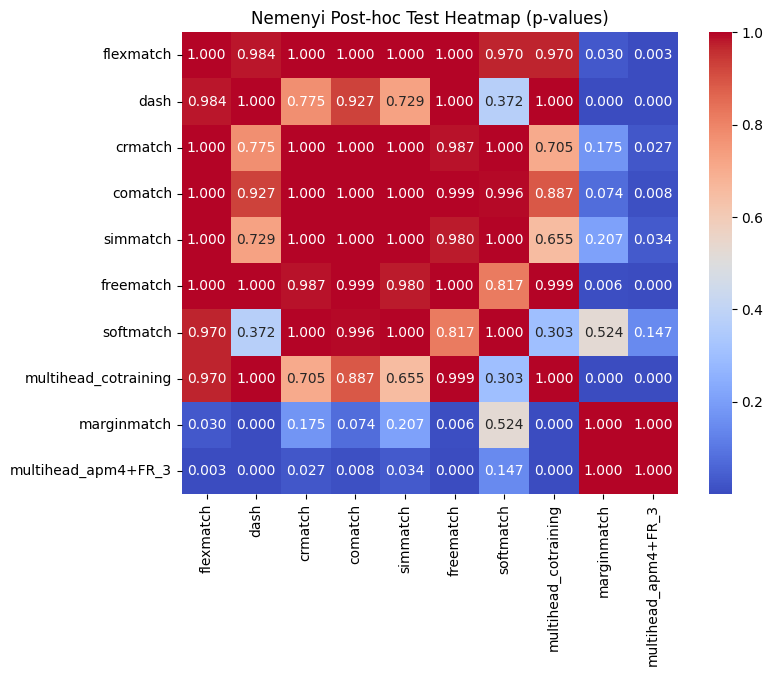

In [43]:
import numpy as np
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

# Example dataset: Error rates of 4 algorithms across 10 datasets
# Lower values are better (e.g., mean squared error)
# data = np.array([
#     [0.12, 0.14, 0.16, 0.20],  # Dataset 1
#     [0.10, 0.13, 0.15, 0.18],  # Dataset 2
#     [0.11, 0.12, 0.14, 0.19],  # Dataset 3
#     [0.13, 0.15, 0.17, 0.22],  # Dataset 4
#     [0.09, 0.12, 0.13, 0.17],  # Dataset 5
#     [0.14, 0.16, 0.18, 0.21],  # Dataset 6
#     [0.11, 0.13, 0.15, 0.19],  # Dataset 7
#     [0.10, 0.11, 0.14, 0.18],  # Dataset 8
#     [0.12, 0.14, 0.16, 0.20],  # Dataset 9
#     [0.09, 0.11, 0.13, 0.17],  # Dataset 10
# ])
# algs = ["A1", "A2", "A3", "A4"]



# Rank the algorithms for each dataset (lower error = better rank)
ranks = np.argsort(np.argsort(data, axis=1), axis=1) + 1

# Compute the Friedman Test
friedman_stat, p_value = stats.friedmanchisquare(*data.T)

print(f"Friedman Test Statistic: {friedman_stat:.4f}, p-value: {p_value:.4f}")

# If p-value is significant, perform Nemenyi Test
if p_value < 0.05:
    print("Significant differences found, performing Nemenyi Post-hoc Test...")
    
    # Perform Nemenyi Test
    nemenyi_results = sp.posthoc_nemenyi_friedman(data)

    # Display Results
    print("Nemenyi Test Results (p-values):")
    print(nemenyi_results)

    # Plot Critical Difference Diagram
    plt.figure(figsize=(8, 6))
    sns.heatmap(nemenyi_results, annot=True, cmap="coolwarm", fmt=".3f", xticklabels=algs, yticklabels=algs)
    plt.title("Nemenyi Post-hoc Test Heatmap (p-values)")
    plt.show()
else:
    print("No significant differences found between algorithms.")


In [16]:
from scipy.stats import ttest_ind

In [21]:
ttest_ind([
    0.9306,
0.9318,
0.9310
], [
    0.9237,
0.9292,
0.9313
])

Ttest_indResult(statistic=1.337271457239923, pvalue=0.25211299729082715)

In [22]:
ttest_ind([
0.9327,
0.9306,
0.9274
], [
0.9298,
0.9322,
0.9284
])

Ttest_indResult(statistic=0.052664007526500654, pvalue=0.9605248001741191)

In [23]:
ttest_ind(
    [
0.8984,
0.8864,
0.8974
    ], [
0.8886,
0.8804,
0.9001
    ]
)

Ttest_indResult(statistic=0.6341093809420975, pvalue=0.5604612184601296)

In [26]:
ttest_ind(
    [
0.6924,
0.6834,
0.6971
    ], [
0.6869,
0.6734,
0.6773
    ]
)

Ttest_indResult(statistic=2.0721729556428756, pvalue=0.10696654948569852)

In [31]:
ttest_ind(
    [
0.5039,
0.4910,
0.4874
    ], [
0.5966,
0.5811,
0.5919
    ]
)

Ttest_indResult(statistic=-14.097907620552407, pvalue=0.00014692774458863943)

In [33]:
ttest_ind([
0.7922,
0.7833,
0.7912
],[
0.7467,
0.7283,
0.7312
])

Ttest_indResult(statistic=8.401874761429179, pvalue=0.0010982611756034661)

In [17]:
marginmatch_res = "7.19±0.39	6.99±0.19	10.65±0.19	11.03±0.99	44.81±1.23	42.14±0.67	32.08±0.70	29.55±0.15	42.93±1.48	39.13±0.34"
multimatch_res = "6.89±0.07	6.98±0.27	11.14±0.96	10.59±0.66	44.43±0.98	42.09±0.28	30.90±0.70	29.39±0.39	42.16±0.79	39.08±0.55"

In [18]:
df = pd.DataFrame({
    'MarginMatch': marginmatch_res.split('\t'),
    'MultiMatch': multimatch_res.split('\t')
})

In [19]:
df['MarginMatch'] = df.MarginMatch.map(lambda x: x.split('±')[0]).astype(float)
df['MultiMatch'] = df.MultiMatch.map(lambda x: x.split('±')[0]).astype(float)

0     7.19
1     6.99
2    10.65
3    11.03
4    44.81
5    42.14
6    32.08
7    29.55
8    42.93
9    39.13
Name: MarginMatch, dtype: float64

In [61]:
df.iloc[range(0, 10, 2)].mean()

MarginMatch    27.532
MultiMatch     27.104
dtype: float64

In [63]:
df.iloc[range(1, 10, 2)].mean()

MarginMatch    25.768
MultiMatch     25.626
dtype: float64

In [65]:
27.532 - 27.104, 25.768 - 25.626, 26.65-26.37

(0.4280000000000008, 0.14199999999999946, 0.2799999999999976)

In [23]:
ablation_table_str = """6.89±0.07	6.98±0.27	11.14±0.96	10.59±0.66	44.43±0.98	42.09±0.28	30.90±0.70	29.39±0.39	42.16±0.79	39.08±0.55
7.08±0.32	7.01±0.31	10.93±0.43	10.73±0.62	44.47±1.11	42.17±0.18	31.24±0.47	29.64±0.51	44.06±1.28	39.41±0.46
7.23±0.18	7.02±0.24	18.41±5.86	11.28±0.86	44.58±0.96	42.08±0.29	36.15±1.36	30.35±0.70	43.94±1.68	39.16±0.36
6.88±0.14	7.46±0.50	15.77±3.04	11.66±0.18	44.57±0.80	42.31±0.36	32.13±0.45	30.35±0.26	44.68±0.89	39.99±0.22
7.09±0.24	6.98±0.20	11.18±0.66	10.56±0.63	44.11±0.79	41.99±0.18	31.14±0.61	29.59±0.27	43.37±0.65	39.17±0.31"""

In [24]:
import pandas as pd
import numpy as np

data = []
algs = []
for s in ablation_table_str.split('\n'):
    l = s.split('\t')[:]
    d = pd.Series(l).map(lambda x: x.split('±')[0]).astype(float).tolist()
    data.append(d)
    algs.append(s.split('\t')[0])
data = np.array(data).T

In [26]:
ranks = np.argsort(np.argsort(data, axis=1), axis=1) + 1

In [27]:
ranks

array([[2, 3, 5, 1, 4],
       [1, 3, 4, 5, 2],
       [2, 1, 5, 4, 3],
       [2, 3, 4, 5, 1],
       [2, 3, 5, 4, 1],
       [3, 4, 2, 5, 1],
       [1, 3, 5, 4, 2],
       [1, 3, 4, 5, 2],
       [1, 4, 3, 5, 2],
       [1, 4, 2, 5, 3]])

In [28]:
avg_ranks = np.mean(ranks, axis=0)

In [29]:
avg_ranks

array([1.6, 3.1, 3.9, 4.3, 2.1])

In [14]:
ablation_table_str = """6.89±0.07	6.98±0.27	11.14±0.96	10.59±0.66	44.43±0.98	42.09±0.28	30.90±0.70	29.39±0.39	42.16±0.79	39.08±0.55
7.08±0.32	7.01±0.31	10.93±0.43	10.73±0.62	44.47±1.11	42.17±0.18	31.24±0.47	29.64±0.51	44.06±1.28	39.41±0.46
7.19±0.29	7.20±0.17	11.80±0.88	10.53±0.27	44.19±0.79	42.13±0.27	31.12±0.75	29.63±0.31	43.20±1.24	39.61±0.14
7.23±0.18	7.02±0.24	18.41±5.86	11.28±0.86	44.58±0.96	42.08±0.29	36.15±1.36	30.35±0.70	43.94±1.68	39.16±0.36
6.88±0.14	7.46±0.50	15.77±3.04	11.66±0.18	44.57±0.80	42.31±0.36	32.13±0.45	30.35±0.26	44.68±0.89	39.99±0.22
7.09±0.24	6.98±0.20	11.18±0.66	10.56±0.63	44.11±0.79	41.99±0.18	31.14±0.61	29.59±0.27	43.37±0.65	39.17±0.31"""

In [15]:
import pandas as pd
import numpy as np

data = []
algs = []
for s in ablation_table_str.split('\n'):
    l = s.split('\t')[:]
    d = pd.Series(l).map(lambda x: x.split('±')[0]).astype(float).tolist()
    data.append(d)
    algs.append(s.split('\t')[0])
data = np.array(data).T

ranks = np.argsort(np.argsort(data, axis=1), axis=1) + 1
avg_ranks = np.mean(ranks, axis=0)
avg_ranks

array([1.8, 3.7, 3.3, 4.6, 5.2, 2.4])